<a href="https://colab.research.google.com/github/vad-source/NLPAPP/blob/main/DIALOGUE/NLPAPP_RAG_Based_Dialogue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## NLP APPLICATIONS
**Designed by:** RAJA VADHANA PRABHAKAR  
**Organization:** BITS PILANI WILP  
**Purpose:** Academic Training / Proof of Concept  

---
#### Attribution & AI Disclosure
- **Original Design:** The logic, architecture, and modular structure of this notebook were designed by the author.
- **Development Assistance:** Generative AI (e.g., ChatGPT/Claude/Copilot) was used for coding implementation and debugging support.
- **License:** This work is licensed under the [Apache License 2.0](https://apache.org).

In [ ]:
!pip install transformers sentence-transformers faiss-cpu gradio accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 64.1 MB/s eta 0:00:00


In [ ]:
import gradio as gr
import faiss
import numpy as np
import json
import re

from transformers import pipeline
from sentence_transformers import SentenceTransformer

In [ ]:
from transformers import pipeline

generator = pipeline( "text-generation", model="TinyLlama/TinyLlama-1.1B-Chat-v1.0", device_map="auto")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

## **0 : Knowledge Base**

### Source Data

In [ ]:
ecommerce_docs = ["""Return Policy:Products can be returned within 7 days.Refunds processed in 5 business days.""",
"""Order Tracking:Customers can track orders using order ID.""",
"""Shipping:Free shipping above Rs. 1000."""
]

In [ ]:
gov_docs = ["""Passport Services:Passport renewal takes 14 days.""",
"""Driving License:Online slot booking available.""",
"""Income Certificate:Apply through district portal."""
]

#### To simulate Vector DB store and creation of knowledge base

In [ ]:
def build_vector_store(documents):
    embeddings = embedder.encode(documents)
    dimension = embeddings.shape[1]
    index = faiss.IndexFlatL2(dimension)
    index.add(np.array(embeddings))
    return index, embeddings

## **1 : Dialogue Processor**

#### **Memory**

In [ ]:
memory = {"short_term": [],"episodic": [],"long_term": {"frequent_issue": None}}

#### Dialogue State

In [ ]:
#dialogue_state = {"intent": None,"order_id": None,"document_type": None,"sentiment": None}
dialogue_state = {"intent": None,"order_id": None,"product": None,"issue_type": None,"current_step": None,"task_complete": False}

In [ ]:
conversation_history = []

###**1.1 NLU**
Conversation Processor

#### Intent Classifier + NER
* LLM Based

In [ ]:
#In-Context Learning"
FEW_SHOT = """
Example:
User:Track my order
Output:{ "intent":"track_order"}

Example:
User:How to renew passport?
Output:{ "intent":"passport_query"}

Example:
User:I want to return shoes
Assistant:Sure. Please provide your order ID.

User:ORD123
Assistant: Thank you. When did you purchase them?
"""

In [ ]:
import json
import re

def extract_intent_slots(user_input):
    prompt = f"""  {SYSTEM_PROMPT} {FEW_SHOT} Conversation History: {conversation_history} Current User Input: {user_input}
    Extract:- intent - order_id - document_type - sentiment  - product - issue_type   Return ONLY JSON.
    User: {user_input} """
    output = generator(prompt, max_new_tokens=20, temperature=0.1)
    text = output[0]["generated_text"]
    match = re.search(r'\{.*\}', text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group())
        except:
            pass
    return {"intent": "unknown"}

### **1.2 Dialogue Manager**

#### CoReference Resolution

#### Policy Management

In [ ]:
def next_action():
    intent = dialogue_state["intent"]
    if intent == "return_product":
        if dialogue_state["order_id"] is None:
            dialogue_state["current_step"] = "ask_order_id"
            return "Please provide your order ID."
        elif dialogue_state["product"] is None:
            dialogue_state["current_step"] ="ask_product"
            return "Which product do you want to return?"
        else:
            dialogue_state["task_complete"] = True
            return  "Your return request has been initiated."

    elif intent == "track_order":
        if dialogue_state["order_id"] is None:
            return "Please provide order ID."
        else:
            dialogue_state["task_complete"] = True
            return f"Tracking order {dialogue_state['order_id']}."
    else:
        return "open_domain"

### **1.3 Memory Manager**
Memory/Context/State Tracker

In [ ]:
#DST
def update_state(extracted):
    for k, v in extracted.items():
        if v:
            dialogue_state[k] = v

In [ ]:
# If needed limit context window of dialogue
#MAX_MEMORY = 5
#memory["short_term"] = memory["short_term"][-MAX_MEMORY:]

### **1.4 Other Helper Functions**

In [ ]:
def reset_system():
    global dialogue_state
    global memory
    global feedback_log
    dialogue_state = {"intent": None, "source": None,"destination": None,"date": None,"time": None,"passenger_name": None, "confirmed": False
    }
    #memory = memory()
    feedback_log = []
    print("System reset complete.")

## **2 : Document Processor**

In [ ]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
ecom_index, ecom_embeddings = build_vector_store(ecommerce_docs)
gov_index, gov_embeddings = build_vector_store(gov_docs)

## **3 : Retriever/ Reasoner**

In [ ]:
def retrieve(query):
    query_embedding = embedder.encode([query])
    mode = "E-Commerce"
    if mode == "E-Commerce":
        D, I = ecom_index.search(np.array(query_embedding), k=2)
        docs = [ecommerce_docs[i] for i in I[0]]
    else:
        D, I = gov_index.search(np.array(query_embedding), k=2)
        docs = [gov_docs[i] for i in I[0]]
    return docs

## **4 : Generator**
Response Generation NLG

In [ ]:
def generate_response(user_input, docs):
    history = "\n".join(conversation_history[-6:])
    context = "\n".join(docs)
    prompt = f"""{SYSTEM_PROMPT} Conversation History:{conversation_history}  Retrieved Context: {context}  User: {user_input} Generate conversational assistant response.
    """
    output = generator(prompt,max_new_tokens=20, temperature=0.7 )
    text = output[0]["generated_text"]
    return text.split("Generate conversational assistant response.")[-1]

## **5 : Response Processor(Validation)**

In [ ]:
def detect_prompt_injection(user_input):
    blocked = ["ignore previous instructions", "reveal system prompt" ]
    for b in blocked:
        if b.lower() in user_input.lower():
            return True
    return False

## **6 : Evaluator**

In [ ]:
evaluation_logs = {"intent_predictions": [],"slot_predictions": [], "coreference_results": [],"adjacency_pairs": [],
    "generation_quality": [], "feedback_scores": []}

In [ ]:
#Instruction Tuning Equivalent
SYSTEM_PROMPT = """
You are an intelligent conversational AI support assistant.

Rules:
1. Use retrieved documents only
2. Do not hallucinate
3. Ask clarification when needed
4. Maintain conversation context
5. Be concise and helpful
6. Maintain conversation context
7. Complete tasks step-by-step
8. Be conversational
"""

In [ ]:
def evaluate_intent_accuracy():
    total = len(evaluation_logs["intent_predictions"])
    if total == 0:
        print("Intent Accuracy: No data")
        return
    correct = 0
    # Simulated ground truth
    for item in evaluation_logs["intent_predictions"]:
        predicted = item["predicted_intent"]
        # simplistic evaluation
        if predicted != "unknown":
            correct += 1
    accuracy = correct / total
    print(f"Intent Accuracy: {accuracy:.2f}")

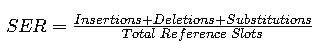

In [ ]:
def evaluate_slot_filling():
    total_slots = 0
    extracted_slots = 0
    for item in evaluation_logs["slot_predictions"]:
        slots = item["predicted_slots"]
        total_slots += 3
        extracted_slots += len(slots)
    ser = 1 - (extracted_slots / total_slots)
    print(f"Slot Error Rate (SER): {ser:.2f}")

In [ ]:
coreference_tests = [{"context_destination": "delhi","input": "I want to go there",  "expected": "I want to go delhi"}]



In [ ]:
def evaluate_coreference():
    total = len(evaluation_logs["coreference_results"])
    if total == 0:
        print("Coreference Score: No data")
        return
    resolved = 0
    for item in evaluation_logs["coreference_results"]:
        if item["original"] != item["resolved"]:
            resolved += 1
    score = resolved / total
    print(f"Coreference Resolution Score: {score:.2f}")

In [ ]:
def evaluate_adjacency_pairs():
    total = len(evaluation_logs["adjacency_pairs"])
    if total == 0:
        print("Adjacency Pair Score: No data")
        return
    coherent = 0
    for pair in evaluation_logs["adjacency_pairs"]:
        response = pair["system"]
        if len(response) > 0:
            coherent += 1
    score = coherent / total
    print(f"Adjacency Pair Score: {score:.2f}")

In [ ]:
def evaluate_generation_quality():
    total = len(evaluation_logs["generation_quality"])
    if total == 0:
        print("Generation Quality: No data")
        return
    avg_length = 0
    for item in evaluation_logs["generation_quality"]:
        avg_length += item["length"]
    avg_length /= total
    print(f"Average Response Length: {avg_length:.2f}")

In [ ]:
def evaluate_task_success_rate():
    required_slots = [ "source","destination","date"]
    success = all(dialogue_state[x] for x in required_slots)
    print(f"Task Success: {success}")

In [ ]:
def evaluate_feedback():
    scores = evaluation_logs["feedback_scores"]
    if len(scores) == 0:
        print("User Feedback Score: No feedback")
        return
    avg = sum(scores) / len(scores)
    print(f"Average User Feedback: {avg:.2f}/5")

In [ ]:
def run_full_evaluation():
    print("\n")
    print("========================================")
    print(" CONVERSATIONAL AI EVALUATION REPORT ")
    print("========================================")
    evaluate_intent_accuracy()
    evaluate_slot_filling()
    evaluate_coreference()
    evaluate_adjacency_pairs()
    evaluate_generation_quality()
    evaluate_feedback()
    evaluate_task_success_rate()
    print("========================================")

## **Pipeline**

#### Single Turn QA

In [ ]:
def chatbotQA(user_input, mode):
    if detect_prompt_injection(user_input):
        return "Prompt injection detected."
    memory["short_term"].append(user_input)
    extracted = extract_intent_slots(user_input)
    update_state(extracted)
    intent = extracted.get("intent","unknown")
    action = next_action(intent)
    if action == "ask_order_id":
        response = "Please provide order ID."
    else:
        docs = retrieve(user_input, mode)
        response = generate_response(user_input, docs)

    evaluation_logs["intent_predictions"].append({"input": user_input,"predicted_intent": intent})
    evaluation_logs["slot_predictions"].append({"input": user_input,"predicted_slots": extracted})
    evaluation_logs["adjacency_pairs"].append({"user": user_input,"system": response})
    evaluation_logs["generation_quality"].append({"response": response,"length": len(response.split())
    })

    return response

In [ ]:
interface = gr.Interface(fn=chatbot,inputs=[gr.Textbox(label="User Query"),gr.Radio(["E-Commerce", "Government"],label="Mode")],
    outputs="text", title="RAG Conversational AI")
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ddf6bb58d819596366.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#### MultiTurn Conv

In [ ]:
def chatbotMul(user_input, chat_history):
    if detect_prompt_injection(user_input):
        return "Unsafe input detected."
    memory["short_term"].append(user_input)
    conversation_history.append(f"User: {user_input}")
    extracted = extract_intent_slots(user_input)
    update_state(extracted)
    policy_response = next_action()
    if policy_response != "open_domain":
        response = policy_response
    else:
        docs = retrieve(user_input)
        response = generate_response( user_input,docs)
    conversation_history.append(f"Assistant: {response}")
    evaluation_logs["intent_predictions"].append({"input": user_input,"predicted_intent": extracted.get("intent", "unknown")})
    evaluation_logs["slot_predictions"].append({"input": user_input,"predicted_slots": extracted})
    evaluation_logs["adjacency_pairs"].append({"user": user_input,"system": response})
    chat_history.append((user_input, response))
    return chat_history

In [ ]:
with gr.Blocks() as demo:
    chatbot_ui = gr.Chatbot()
    msg = gr.Textbox()
    clear = gr.Button("Clear")
    state = gr.State([])
    msg.submit( chatbot,[msg, state],chatbot_ui )
    clear.click(lambda: [], None,chatbot_ui)
demo.launch()

/tmp/ipykernel_9772/1195985617.py:2: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot_ui = gr.Chatbot()
/tmp/ipykernel_9772/1195985617.py:2: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot_ui = gr.Chatbot()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c188f338a3e13ded3f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#### Final

In [ ]:
def chatbot():
    print("\nBot: Hello! How can I help you?\n")
    while True:
        user_input = input("User: ")
        if user_input.lower() == "exit":
            print("Bot: Goodbye!")
            break
        if detect_prompt_injection(user_input):
            print("Unsafe input or prompt detected.")
            continue

        memory["short_term"].append(user_input)
        conversation_history.append(f"User: {user_input}")
        extracted = extract_intent_slots(user_input)
        update_state(extracted)
        policy_response = next_action()
        if policy_response != "open_domain":
            response = policy_response
        else:
            docs = retrieve(user_input)
            response = generate_response( user_input,docs)
        print("\nBot:", response)
        conversation_history.append(f"Assistant: {response}")
        evaluation_logs["intent_predictions"].append({"input": user_input,"predicted_intent": extracted.get("intent", "unknown")})
        evaluation_logs["slot_predictions"].append({"input": user_input,"predicted_slots": extracted})
        evaluation_logs["adjacency_pairs"].append({"user": user_input,"system": response})
        evaluation_logs["generation_quality"].append({"response": response,"length":len(response.split())})

        if dialogue_state["task_complete"]:
            feedback = int(input( "\nRate experience (1-5): "))
            evaluation_logs["feedback_scores"].append(feedback)
            print("\nTask completed.\n")

        #chat_history.append((user_input, response))
   #return chat_history

In [ ]:
reset_system()

System reset complete.


In [ ]:
chatbot()


Bot: Hello! How can I help you?

User: Want to sell my shorts


Both `max_new_tokens` (=20) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Bot: 
    1. Use retrieved documents only
    2. Do not hallucinate
    3. Ask


KeyError: 'task_complete'

In [ ]:
run_full_evaluation()



 CONVERSATIONAL AI EVALUATION REPORT 
Intent Accuracy: 0.00
Slot Error Rate (SER): 0.67
Coreference Score: No data
Adjacency Pair Score: 1.00
Average Response Length: 44.00
User Feedback Score: No feedback
Task Success: False


In [ ]:
#If reset doesn't work run below
#import os
#os.kill(os.getpid(), 9)